## **Figure-S15**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

import seaborn as sns
sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


---

In [3]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014')
condition = dict(orig='Initial', refined='Reference-based')

#### **Load Data**

In [4]:
# Bruker data
osw = { n:defaultdict(dict) for n in names.values() }

osw[names['bruker']][condition['orig']] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_25ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_5ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_100ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")

# Silico data
osw[names['silico']][condition['orig']] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_25ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_5ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_100ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")

# Experimental data
osw[names['exp']][condition['orig']] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['exp']][condition['refined'] + '_25ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['exp']][condition['refined'] + '_5ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['exp']][condition['refined'] + '_100ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")

# PanHuman data
osw[names['panhuman']][condition['orig']] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_25ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_5ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_100ngLib'] = getPrecursorDf_Characteristics_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")

../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDe

In [5]:
osw_frag_intens = defaultdict(dict)


# Bruker data
osw_frag_intens[names['bruker']][condition['orig']] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", norm_factor=10000)
osw_frag_intens[names['bruker']][condition['refined'] + '_25ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", norm_factor=10000)
osw_frag_intens[names['bruker']][condition['refined'] + '_5ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", norm_factor=10000)
osw_frag_intens[names['bruker']][condition['refined'] + '_100ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", norm_factor=10000)


# Silico data
osw_frag_intens[names['silico']][condition['orig']] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=1)
osw_frag_intens[names['silico']][condition['refined'] + '_25ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)
osw_frag_intens[names['silico']][condition['refined'] + '_5ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)
osw_frag_intens[names['silico']][condition['refined'] + '_100ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)

# Experimental data
osw_frag_intens[names['exp']][condition['orig']] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)
osw_frag_intens[names['exp']][condition['refined'] + '_25ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", norm_factor=10000)
osw_frag_intens[names['exp']][condition['refined'] + '_5ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", norm_factor=10000)
osw_frag_intens[names['exp']][condition['refined'] + '_100ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", norm_factor=10000)

# PanHuman data
osw_frag_intens[names['panhuman']][condition['orig']] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)
osw_frag_intens[names['panhuman']][condition['refined'] + '_25ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)
osw_frag_intens[names['panhuman']][condition['refined'] + '_5ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)
osw_frag_intens[names['panhuman']][condition['refined'] + '_100ngLib'] = compute_frag_intensity_residuals_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/", norm_factor=10000)

../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDe

In [6]:
tmp = {}
for k, v in osw_frag_intens.items():
    tmp[k] = pd.concat(v).reset_index(names=['Condition', 'i']).drop(columns='i')
    
osw_frag = pd.concat(tmp).reset_index(names=['Library', 'i']).drop(columns='i')
    

In [7]:
tmp = {}
for i in osw.keys():
    tmp[i] = pd.concat(osw[i]).reset_index(names=['Condition', 0]).drop(columns=0)
osw_df = pd.concat(tmp).reset_index(names=['Library', 0]).drop(columns=0)

In [8]:
osw_df

,Library,Condition,FEATURE.DELTA_RT,FEATURE_MS2.VAR_LIBRARY_DOTPROD,FEATURE_MS2.DELTA_IM,Precursor,FEATURE.EXP_RT,FEATURE_MS2.EXP_IM,PRECURSOR.LIBRARY_RT,PRECURSOR.LIBRARY_DRIFT_TIME
0,Experimental,Initial,-8.141610,0.993114,-0.004341,RNSTIPTK2,1397.68,0.811428,8.232453,0.813046
1,Experimental,Initial,34.073900,0.903298,-0.012505,SEQEDEVLLVSSSR2,4308.35,1.065939,64.171224,1.068436
2,Experimental,Initial,3.056240,0.915494,-0.008358,EIEC(UniMod:4)SIAGAHEK2,2266.63,1.003490,25.554456,1.007994
3,Experimental,Initial,4.994420,0.956637,-0.001472,VGHSELVGEIIR3,4152.32,0.784847,61.864120,0.788464
4,Experimental,Initial,-13.546600,0.949236,-0.020295,SDAPDTLLLEK2,4580.05,0.929564,69.900248,0.918979
...,...,...,...,...,...,...,...,...,...,...
304243,"PanHuman, 2014",Reference-based_100ngLib,3.629660,0.990027,0.002523,VVNPLFEK2,4306.60,0.823584,61.974198,0.846751
304244,"PanHuman, 2014",Reference-based_100ngLib,-0.240349,0.987874,0.017499,SNM(UniMod:35)GHPEPASGLAALAK3,3977.17,0.777916,55.780239,0.815715
304245,"PanHuman, 2014",Reference-based_100ngLib,-4.929000,0.965188,0.008757,VVESPDFSK2,2842.80,0.841025,33.941934,0.870692
304246,"PanHuman, 2014",Reference-based_100ngLib,1.951620,0.729205,-0.008074,KPAPVPAEPFDNTTYK3,3722.27,0.810769,50.794367,0.823078


#### **Plot**

In [9]:
def create_characteristics_boxplot(ax, data, y, ylabel, show_xticks, ylim=None, font_size_small=7, font_size_medium=10, font_size_large=11):
    sns.set_palette(["tab:blue", "#FFAA62", "tab:orange", "#CC6500"])
    sns.boxplot(data=data,
                x='Library', 
                hue='Condition', 
                y=y, showfliers=False, ax=ax, order=names.values(), legend=False, hue_order=[condition['orig']] + [condition['refined'] + f'_{x}ngLib' for x in ['5', '25', '100'] ])
    ax.set_ylabel(ylabel, fontsize=font_size_medium)
    ax.axhline(0, color='black')

    if not show_xticks:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Library", fontsize=font_size_medium)
        for l in ax.get_xticklabels():
            if l.get_text() == 'in-silico':
                l.set_fontstyle('italic')
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    if ylim is not None:
        ax.set_ylim(ylim)


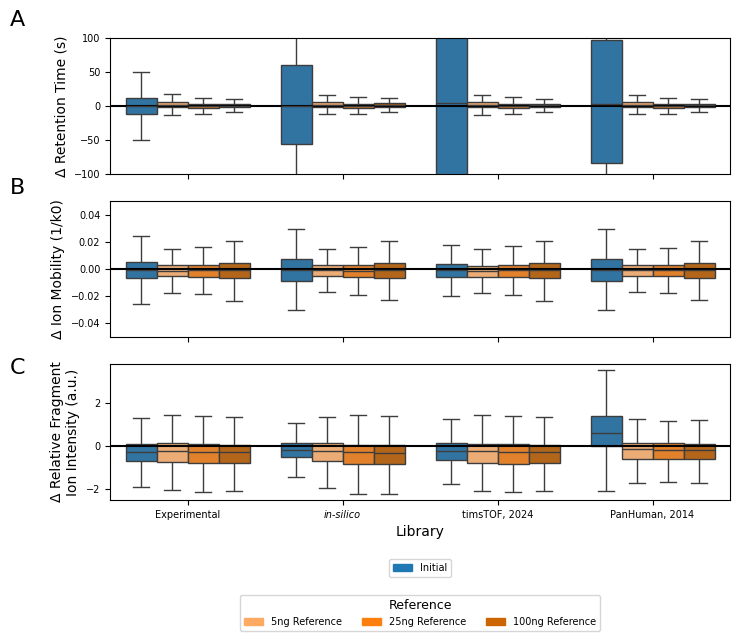

In [10]:
fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

create_characteristics_boxplot(ax1, osw_df, 'FEATURE.DELTA_RT', 'Δ Retention Time (s)', show_xticks=False, ylim=(-100, 100))

create_characteristics_boxplot(ax2, osw_df, 'FEATURE_MS2.DELTA_IM', 'Δ Ion Mobility (1/k0)', show_xticks=False, ylim=(-0.05, 0.05))

create_characteristics_boxplot(ax3, osw_frag, 'residual', 'Δ Relative Fragment\nIon Intensity (a.u.)', show_xticks=True)

# add legend for plots 
initial_patch = mpatches.Patch(color='tab:blue', label='Initial')

reference_5ng = mpatches.Patch(color='#FFAA62', label='5ng Reference')
reference_25ng = mpatches.Patch(color='#FF7F0E', label='25ng Reference')
reference_100ng = mpatches.Patch(color='#CC6500', label='100ng Reference')

# --- 2. Create the First Legend (Initial) ---
# This legend is placed below the second one.
legend1 = ax3.legend(
    handles=[initial_patch],
    loc='lower center',
    fontsize=7,
    bbox_to_anchor=(0.5, -0.6), # Moves the legend outside and below the plot
)

# --- 3. Create the Second Legend (Reconstructed) ---
legend2 = ax3.legend(
    handles=[reference_5ng, reference_25ng, reference_100ng],
    title='Reference',
    loc='lower center',
    bbox_to_anchor=(0.5, -1), # Positions it next to the first legend
    fontsize=7,
    title_fontsize=9,
    ncol=3
)

ax3.add_artist(legend1)

fig.text(0, 0.9, 'A', fontsize=16) 
fig.text(0, 0.62, 'B', fontsize=16)
fig.text(0, 0.32, 'C', fontsize=16) 

plt.savefig("Figure-S15.png", dpi=300, bbox_inches='tight')
